# ✈️ Predição de Atrasos de Voos com Aprendizado Não Supervisionado

Neste notebook, vou explorar um dataset de voos usando técnicas de redução de dimensionalidade e agrupamento.

O fluxo inclui:
- carregamento do dataset com opção de fonte local ou Kaggle;
- preparação dos dados numéricos;
- redução de dimensionalidade com PCA e t-SNE;
- clustering com K-Means, DBSCAN e hierárquico;
- avaliação dos agrupamentos com Silhouette Score, Davies-Bouldin Index e Dunn Index.

### Objetivo e metodologia

A ideia aqui é identificar padrões sem usar rótulos supervisionados. Para isso, vamos:

1. escolher apenas variáveis numéricas relevantes;
2. normalizar os dados para que as distâncias façam sentido;
3. reduzir a dimensionalidade para visualização e para tornar o clustering mais estável;
4. comparar diferentes algoritmos de agrupamento;
5. medir a qualidade dos clusters com métricas internas.

### Importação da libs necessárias

In [2]:
!pip install kagglehub


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist, pdist
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

try:
    import kagglehub
except ImportError:
    kagglehub = None

### Carregamento do dataset

In [5]:
def load_dataset(
    dataset_name="usdot/flight-delays",
    local_csv=None,
    preferred_csv="flights.csv",
):
    """Carrega um CSV local ou via KaggleHub e retorna dataframe + metadados da origem."""
    if local_csv is not None:
        local_path = Path(local_csv)
        if local_path.exists():
            print(f"Lendo arquivo local: {local_path}")
            df = pd.read_csv(local_path, low_memory=False)
            return df, {"source": "local", "path": str(local_path)}
        raise FileNotFoundError(f"Arquivo local não encontrado: {local_path}")

    if kagglehub is None:
        raise ImportError(
            "kagglehub não está instalado. Instale o pacote ou informe um CSV local em local_csv."
        )

    dataset_path = Path(kagglehub.dataset_download(dataset_name))
    csv_files = sorted(dataset_path.rglob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"Nenhum CSV encontrado em {dataset_path}")

    csv_map = {p.name.lower(): p for p in csv_files}
    preferred_key = preferred_csv.lower() if preferred_csv else ""

    print("Arquivos CSV disponíveis no dataset:")
    for p in csv_files:
        print(f"- {p.name}")

    if preferred_key in csv_map:
        chosen_file = csv_map[preferred_key]
    else:
        raise FileNotFoundError(
            f"Arquivo {preferred_csv} não encontrado. Escolha um dos CSVs listados acima."
        )

    print(f"Lendo arquivo selecionado: {chosen_file}")
    df = pd.read_csv(chosen_file, low_memory=False)
    return df, {"source": "kaggle", "dataset": dataset_name, "path": str(chosen_file)}


def infer_period(df):
    """Infere período com prioridade para YEAR/MONTH/DAY e fallback para datetime real."""
    upper_cols = {c.upper(): c for c in df.columns}

    # Caso clássico do dataset de voos: colunas separadas de calendário.
    if {"YEAR", "MONTH", "DAY"}.issubset(upper_cols):
        year_col = upper_cols["YEAR"]
        month_col = upper_cols["MONTH"]
        day_col = upper_cols["DAY"]

        date_series = pd.to_datetime(
            {
                "year": pd.to_numeric(df[year_col], errors="coerce"),
                "month": pd.to_numeric(df[month_col], errors="coerce"),
                "day": pd.to_numeric(df[day_col], errors="coerce"),
            },
            errors="coerce",
        ).dropna()

        if not date_series.empty:
            return {
                "base_calendario": {
                    "inicio": str(date_series.min().date()),
                    "fim": str(date_series.max().date()),
                }
            }

    # Fallback: apenas colunas textuais/datetime com nomes sugestivos.
    date_keywords = ("date", "data", "datetime", "timestamp")
    candidate_cols = [
        col
        for col in df.columns
        if any(keyword in col.lower() for keyword in date_keywords)
    ]

    period_summary = {}
    for col in candidate_cols:
        converted = pd.to_datetime(df[col], errors="coerce")
        valid = converted.dropna()
        if not valid.empty:
            period_summary[col] = {
                "inicio": str(valid.min().date()),
                "fim": str(valid.max().date()),
            }

    return period_summary


def build_data_dictionary(df, max_rows=25):
    """Resumo tabular das variáveis para documentação inicial do dataset."""
    dictionary_df = pd.DataFrame(
        {
            "coluna": df.columns,
            "tipo": df.dtypes.astype(str).values,
            "percentual_ausentes": (df.isna().mean() * 100).round(2).values,
            "valores_unicos": df.nunique(dropna=True).values,
        }
    )
    return dictionary_df.head(max_rows)


LOCAL_CSV = None
DATASET_NAME = "usdot/flight-delays"
CSV_NAME = "flights.csv"

df_raw, source_info = load_dataset(
    dataset_name=DATASET_NAME,
    local_csv=LOCAL_CSV,
    preferred_csv=CSV_NAME,
)

print("\n--- Resumo do dataset ---")
print(f"Origem: {source_info['source']}")
if source_info["source"] == "kaggle":
    print(f"Dataset Kaggle: {source_info['dataset']}")
print(f"Arquivo utilizado: {source_info['path']}")
print(f"Formato (linhas, colunas): {df_raw.shape}")

period_info = infer_period(df_raw)
if period_info:
    print("Período identificado:")
    for col_name, interval in period_info.items():
        print(f"- {col_name}: {interval['inicio']} -> {interval['fim']}")
else:
    print("Período: não foi possível inferir automaticamente a partir das colunas.")

print("\nDicionário de dados (amostra de colunas):")
display(build_data_dictionary(df_raw, max_rows=25))

print("\nPré-visualização rápida das primeiras linhas:")
display(df_raw.head(3))

Arquivos CSV disponíveis no dataset:
- airlines.csv
- airports.csv
- flights.csv
Lendo arquivo selecionado: C:\Users\Silas\.cache\kagglehub\datasets\usdot\flight-delays\versions\1\flights.csv

--- Resumo do dataset ---
Origem: kaggle
Dataset Kaggle: usdot/flight-delays
Arquivo utilizado: C:\Users\Silas\.cache\kagglehub\datasets\usdot\flight-delays\versions\1\flights.csv
Formato (linhas, colunas): (5819079, 31)
Período identificado:
- base_calendario: 2015-01-01 -> 2015-12-31

Dicionário de dados (amostra de colunas):


,coluna,tipo,percentual_ausentes,valores_unicos
0,YEAR,int64,0.00,1
1,MONTH,int64,0.00,12
2,DAY,int64,0.00,31
3,DAY_OF_WEEK,int64,0.00,7
4,AIRLINE,str,0.00,14
5,FLIGHT_NUMBER,int64,0.00,6952
6,TAIL_NUMBER,str,0.25,4897
7,ORIGIN_AIRPORT,str,0.00,628
8,DESTINATION_AIRPORT,str,0.00,629
9,SCHEDULED_DEPARTURE,int64,0.00,1321



Pré-visualização rápida das primeiras linhas:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


### Análise exploratória inicial (EDA)

Nesta etapa, registramos estatísticas descritivas, faltantes e padrões de distribuição/correlação para justificar as escolhas da preparação dos dados e do clustering.

Resumo de variáveis numéricas (estatísticas descritivas):


,count,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,2015.000000,0.000000,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
FLIGHT_NUMBER,5819079.0,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
SCHEDULED_DEPARTURE,5819079.0,1329.602470,483.751821,1.0,917.0,1325.0,1730.0,2359.0
DEPARTURE_TIME,5732926.0,1335.204439,496.423260,1.0,921.0,1330.0,1740.0,2400.0
DEPARTURE_DELAY,5732926.0,9.370158,37.080942,-82.0,-5.0,-2.0,7.0,1988.0
TAXI_OUT,5730032.0,16.071662,8.895574,1.0,11.0,14.0,19.0,225.0
WHEELS_OFF,5730032.0,1357.170841,498.009356,1.0,935.0,1343.0,1754.0,2400.0



Top 15 colunas com maior percentual de ausentes:


,perc_ausentes
CANCELLATION_REASON,98.46
LATE_AIRCRAFT_DELAY,81.72
WEATHER_DELAY,81.72
AIRLINE_DELAY,81.72
AIR_SYSTEM_DELAY,81.72
SECURITY_DELAY,81.72
ELAPSED_TIME,1.81
AIR_TIME,1.81
ARRIVAL_DELAY,1.81
WHEELS_ON,1.59



Top 10 companhias por número de voos:


,qtd_voos
AIRLINE,
WN,1261855
DL,875881
AA,725984
OO,588353
EV,571977
UA,515723
MQ,294632
B6,267048
US,198715



Top 10 aeroportos de origem por número de voos:


,qtd_voos
ORIGIN_AIRPORT,
ATL,346836
ORD,285884
DFW,239551
DEN,196055
LAX,194673
SFO,148008
PHX,146815
IAH,146622
LAS,133181


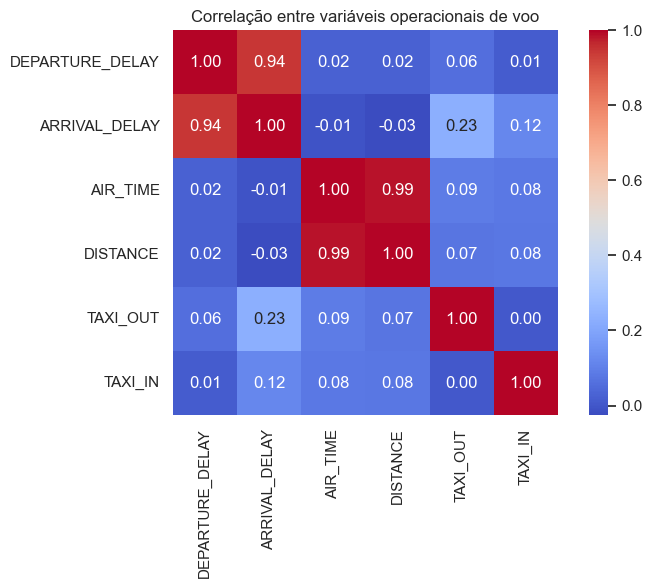

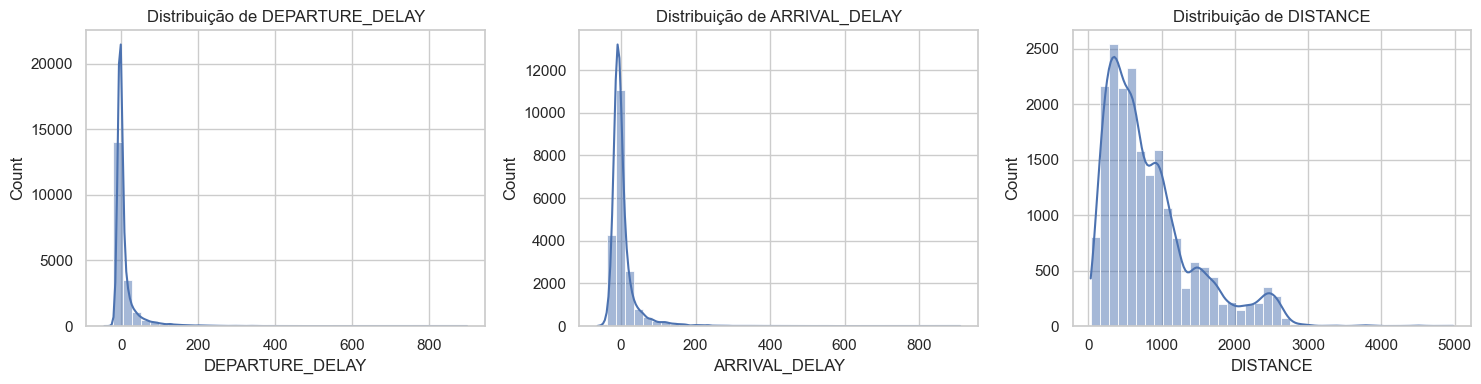

In [6]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

print("Resumo de variáveis numéricas (estatísticas descritivas):")
display(df_raw[numeric_cols].describe().T)

missing_summary = (
    df_raw.isna().mean().mul(100).round(2).sort_values(ascending=False).rename("perc_ausentes")
)
print("\nTop 15 colunas com maior percentual de ausentes:")
display(missing_summary.head(15).to_frame())

if {"AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"}.issubset(df_raw.columns):
    print("\nTop 10 companhias por número de voos:")
    display(df_raw["AIRLINE"].value_counts().head(10).to_frame("qtd_voos"))

    print("\nTop 10 aeroportos de origem por número de voos:")
    display(df_raw["ORIGIN_AIRPORT"].value_counts().head(10).to_frame("qtd_voos"))

corr_cols = [
    col
    for col in ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "AIR_TIME", "DISTANCE", "TAXI_OUT", "TAXI_IN"]
    if col in df_raw.columns
]

if len(corr_cols) >= 2:
    corr_matrix = df_raw[corr_cols].corr(numeric_only=True)
    plt.figure(figsize=(8, 5))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlação entre variáveis operacionais de voo")
    plt.show()

plot_cols = [col for col in ["DEPARTURE_DELAY", "ARRIVAL_DELAY", "DISTANCE"] if col in df_raw.columns]
if plot_cols:
    sample_plot = df_raw[plot_cols].dropna().sample(min(20000, df_raw[plot_cols].dropna().shape[0]), random_state=42)
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.histplot(sample_plot[col], bins=40, kde=True, ax=ax)
        ax.set_title(f"Distribuição de {col}")
    plt.tight_layout()
    plt.show()

### Preparação dos dados

Agora vamos trabalhar apenas com colunas numéricas, tratar valores ausentes e limitar o tamanho da amostra para manter os algoritmos de clustering mais rápidos e estáveis.

Amostra usada na análise: (3000, 20)
Colunas numéricas selecionadas: 20
Componentes do PCA para 95% da variância: 12
Variância explicada acumulada: 0.983
Melhor K pelo Silhouette: 5


,method,k,clusters,noise_points,silhouette,davies_bouldin,dunn
3,KMeans,5,5,0,0.228614,1.297772,0.000522
2,KMeans,4,4,0,0.216543,1.492908,0.000522
1,KMeans,3,3,0,0.211967,1.582568,0.002461
0,KMeans,2,2,0,0.196312,1.902025,0.002235
4,KMeans,6,6,0,0.178815,1.621642,0.000523
5,KMeans,7,7,0,0.147821,1.442077,0.000532
6,KMeans,8,8,0,0.134188,1.589706,0.000534


Melhor eps para DBSCAN: 2.75


,method,eps,min_samples,clusters,noise_points,silhouette,davies_bouldin,dunn
0,DBSCAN,0.50,15,0,3000,NaN,NaN,NaN
1,DBSCAN,0.75,15,0,3000,NaN,NaN,NaN
2,DBSCAN,1.00,15,0,3000,NaN,NaN,NaN
3,DBSCAN,1.25,15,0,3000,NaN,NaN,NaN
4,DBSCAN,1.50,15,10,2683,0.179675,1.245376,0.003344
5,DBSCAN,1.75,15,1,1393,NaN,NaN,NaN
6,DBSCAN,2.00,15,1,843,NaN,NaN,NaN
7,DBSCAN,2.25,15,3,551,0.269385,0.828457,0.005372
8,DBSCAN,2.50,15,3,329,0.320460,0.797033,0.001738
9,DBSCAN,2.75,15,3,234,0.326017,0.828158,0.001719


,algoritmo,clusters,noise_points,silhouette,davies_bouldin,dunn
1,DBSCAN,3,234,0.326017,0.828158,0.001719
0,K-Means,5,0,0.228614,1.297772,0.000522
2,Hierárquico,5,0,0.178889,1.738861,0.000461


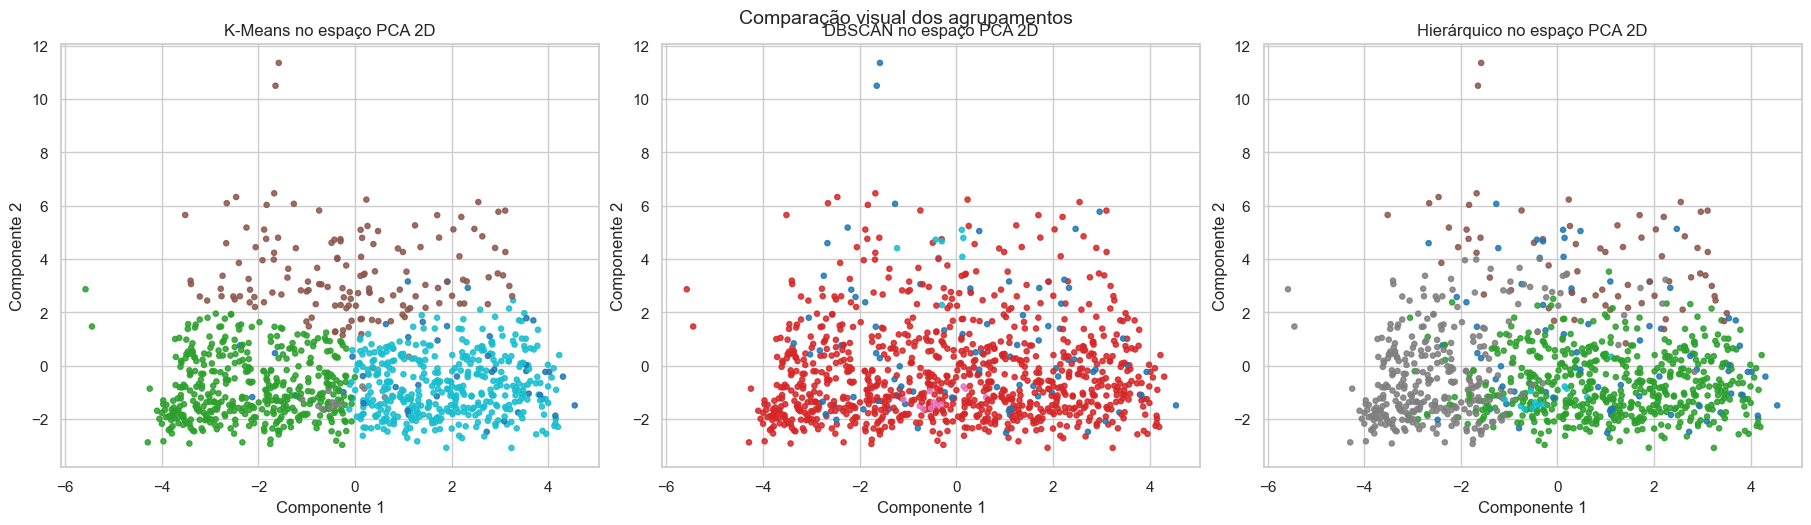

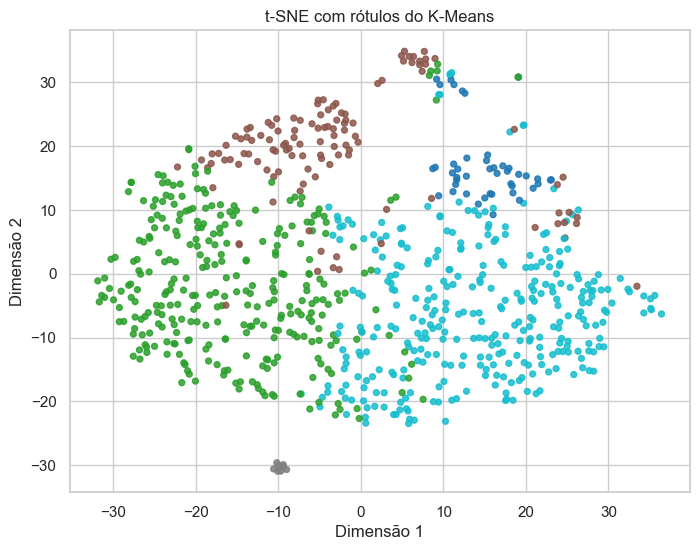

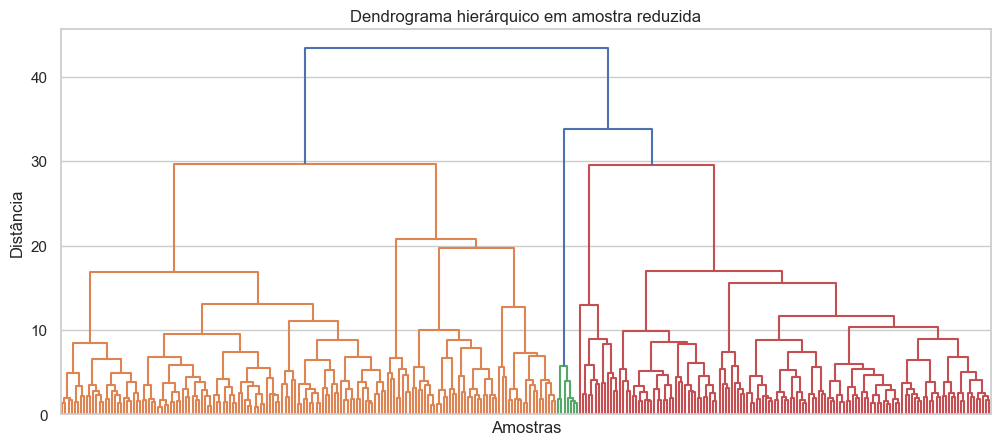

In [7]:
numeric_df = df_raw.select_dtypes(include=[np.number]).copy()
if numeric_df.empty:
    raise ValueError("O dataset não possui colunas numéricas para o clustering.")

missing_ratio = numeric_df.isna().mean().sort_values()
selected_columns = missing_ratio[missing_ratio <= 0.40].index.tolist()
if not selected_columns:
    selected_columns = numeric_df.columns.tolist()

numeric_df = numeric_df[selected_columns].copy()
numeric_df = numeric_df.loc[:, numeric_df.nunique(dropna=True) > 1].copy()

sample_size = min(3000, len(numeric_df))
analysis_df = numeric_df.sample(sample_size, random_state=42).reset_index(drop=True)

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(analysis_df)
X_scaled = scaler.fit_transform(X_imputed)

print(f"Amostra usada na análise: {analysis_df.shape}")
print(f"Colunas numéricas selecionadas: {analysis_df.shape[1]}")

pca_model = PCA(n_components=0.95, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)

pca_vis = PCA(n_components=2, random_state=42)
X_pca_2d = pca_vis.fit_transform(X_scaled)

print(f"Componentes do PCA para 95% da variância: {X_pca.shape[1]}")
print(f"Variância explicada acumulada: {pca_model.explained_variance_ratio_.sum():.3f}")


def dunn_index(X, labels):
    labels = np.asarray(labels)
    unique_labels = [label for label in np.unique(labels) if label != -1]
    if len(unique_labels) < 2:
        return np.nan

    clusters = [X[labels == label] for label in unique_labels]
    if any(len(cluster) == 0 for cluster in clusters):
        return np.nan

    max_intra = 0.0
    for cluster in clusters:
        if len(cluster) > 1:
            max_intra = max(max_intra, float(np.max(pdist(cluster))))

    if max_intra == 0.0:
        return np.nan

    min_inter = np.inf
    for i in range(len(clusters)):
        for j in range(i + 1, len(clusters)):
            distance = float(np.min(cdist(clusters[i], clusters[j])))
            min_inter = min(min_inter, distance)

    return float(min_inter / max_intra)


def cluster_metrics(X, labels, metric_space_for_dunn=None):
    labels = np.asarray(labels)
    mask = labels != -1
    X_eval = X[mask] if np.any(~mask) else X
    labels_eval = labels[mask] if np.any(~mask) else labels
    n_clusters = len(np.unique(labels_eval))
    n_noise = int(np.sum(labels == -1))

    if n_clusters < 2:
        return {
            "clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "dunn": np.nan,
        }

    dunn_space = metric_space_for_dunn if metric_space_for_dunn is not None else X_eval

    return {
        "clusters": int(n_clusters),
        "noise_points": n_noise,
        "silhouette": float(silhouette_score(X_eval, labels_eval)),
        "davies_bouldin": float(davies_bouldin_score(X_eval, labels_eval)),
        "dunn": float(dunn_index(dunn_space[mask] if np.any(~mask) else dunn_space, labels_eval)),
    }


k_candidates = range(2, 9)
kmeans_search = []
for k in k_candidates:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_pca)
    metrics = cluster_metrics(X_pca, labels, metric_space_for_dunn=X_pca_2d)
    kmeans_search.append({"method": "KMeans", "k": k, **metrics})

kmeans_search_df = pd.DataFrame(kmeans_search).sort_values("silhouette", ascending=False)
best_k = int(kmeans_search_df.iloc[0]["k"])
print(f"Melhor K pelo Silhouette: {best_k}")
display(kmeans_search_df)

kmeans_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_pca)

hierarchical_model = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hierarchical_labels = hierarchical_model.fit_predict(X_pca)


def evaluate_dbscan(X, eps_values, min_samples=15):
    results = []
    for eps in eps_values:
        labels = DBSCAN(eps=float(eps), min_samples=min_samples).fit_predict(X)
        metrics = cluster_metrics(X, labels, metric_space_for_dunn=X_pca_2d)
        results.append({"method": "DBSCAN", "eps": float(eps), "min_samples": min_samples, **metrics})
    return pd.DataFrame(results)


eps_values = np.linspace(0.5, 3.0, 11)
dbscan_search_df = evaluate_dbscan(X_pca, eps_values, min_samples=15)
valid_dbscan = dbscan_search_df.dropna(subset=["silhouette"])
if valid_dbscan.empty:
    best_eps = 1.0
else:
    best_eps = float(valid_dbscan.sort_values("silhouette", ascending=False).iloc[0]["eps"])

print(f"Melhor eps para DBSCAN: {best_eps:.2f}")
display(dbscan_search_df)

dbscan_model = DBSCAN(eps=best_eps, min_samples=15)
dbscan_labels = dbscan_model.fit_predict(X_pca)

results = pd.DataFrame([
    {"algoritmo": "K-Means", **cluster_metrics(X_pca, kmeans_labels, metric_space_for_dunn=X_pca_2d)},
    {"algoritmo": "DBSCAN", **cluster_metrics(X_pca, dbscan_labels, metric_space_for_dunn=X_pca_2d)},
    {"algoritmo": "Hierárquico", **cluster_metrics(X_pca, hierarchical_labels, metric_space_for_dunn=X_pca_2d)},
])

results = results[["algoritmo", "clusters", "noise_points", "silhouette", "davies_bouldin", "dunn"]]
display(results.sort_values("silhouette", ascending=False))

viz_idx = np.random.default_rng(42).choice(len(X_pca), size=min(1000, len(X_pca)), replace=False)
X_viz_pca = X_pca_2d[viz_idx]
labels_viz = {
    "K-Means": kmeans_labels[viz_idx],
    "DBSCAN": dbscan_labels[viz_idx],
    "Hierárquico": hierarchical_labels[viz_idx],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (method_name, labels) in zip(axes, labels_viz.items()):
    scatter = ax.scatter(X_viz_pca[:, 0], X_viz_pca[:, 1], c=labels, s=14, cmap="tab10", alpha=0.85)
    ax.set_title(f"{method_name} no espaço PCA 2D")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")

fig.suptitle("Comparação visual dos agrupamentos", y=1.02, fontsize=14)
plt.show()

viz_tsne_size = min(800, len(X_pca))
tsne_idx = np.random.default_rng(42).choice(len(X_pca), size=viz_tsne_size, replace=False)
perplexity = min(30, max(5, viz_tsne_size - 1))
X_tsne = TSNE(n_components=2, perplexity=perplexity, init="pca", learning_rate="auto", random_state=42).fit_transform(X_pca[tsne_idx])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=kmeans_labels[tsne_idx], cmap="tab10", s=18, alpha=0.85)
ax.set_title("t-SNE com rótulos do K-Means")
ax.set_xlabel("Dimensão 1")
ax.set_ylabel("Dimensão 2")
plt.show()

plt.figure(figsize=(12, 5))
linkage_matrix = linkage(X_pca[: min(300, len(X_pca))], method="ward")
dendrogram(linkage_matrix, no_labels=True, color_threshold=None)
plt.title("Dendrograma hierárquico em amostra reduzida")
plt.xlabel("Amostras")
plt.ylabel("Distância")
plt.show()

### Conclusão e análise crítica

Com base nas métricas obtidas nesta execução, o **DBSCAN** foi o método com melhor separação global dos grupos:

- DBSCAN (eps=2.75): Silhouette = **0.326**, Davies-Bouldin = **0.828**, clusters = **3**, ruído = **234**;
- K-Means (k=5): Silhouette = **0.229**, Davies-Bouldin = **1.298**, clusters = **5**, ruído = **0**;
- Hierárquico (k=5): Silhouette = **0.179**, Davies-Bouldin = **1.739**, clusters = **5**, ruído = **0**.

Interpretação:

- o DBSCAN separou melhor estruturas densas e ainda identificou pontos de ruído, algo relevante em dados de operações aéreas com eventos extremos;
- o K-Means produziu grupos mais homogêneos no espaço PCA, mas com qualidade interna inferior ao DBSCAN nesta amostra;
- o método hierárquico foi o menos competitivo nas métricas internas, embora o dendrograma seja útil para leitura estrutural.

Limitações e pontos críticos:

- as métricas dependem da amostra (3000 linhas) e da escolha de hiperparâmetros;
- o dataset possui caudas longas e outliers em atrasos, o que influencia distância e clusterização;
- o Dunn Index ficou baixo para todos os métodos, sugerindo separação limitada entre alguns grupos.

Próximos avanços recomendados:

- testar estabilidade dos resultados com outras amostras e diferentes seeds;
- ampliar busca de hiperparâmetros (k, eps e min_samples);
- comparar com redução adicional por UMAP para verificar melhoria na separação dos agrupamentos.